In [1]:
import ROOT
import os
import glob

In [2]:
fileDirPath = "/d/home/septian/Moments2Amplitudes/brufit/"

files = glob.glob(os.path.join(fileDirPath, "MassDependentResults_*.root"))

print("Found files:")
for f in files:
    print(f)

Found files:
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_184.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_239.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_244.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_206.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_207.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_173.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_204.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_161.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_163.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_195.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_138.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_197.root
/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_192.root
/d/home/septian/Moments2Amplitudes/brufit/MassDepen

In [3]:
# out_log = []
chi2_values = []
# open text file with format "output_$num.txt"
for file in files:
    num = file.split("_")[-1].split(".")[0]
    print(f"Processing file: {file} with output log: output_{num}.txt")
    out_file = f"{fileDirPath}output_{num}.txt"
    if os.path.exists(out_file):
        with open(out_file, 'r') as f:
            # find lines with "Chi2 after minimization: " read number after it
            for line in f:
                if "Chi2 after minimization: " in line:
                    chi2_value = line.split(":")[-1].strip()
                    print(f"Found Chi2 value: {chi2_value} for file {file}")
                    chi2_values.append((file, float(chi2_value)))

Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_184.root with output log: output_184.txt
Found Chi2 value: 267.739 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_184.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_239.root with output log: output_239.txt
Found Chi2 value: 268.04 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_239.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_244.root with output log: output_244.txt
Found Chi2 value: 274.02 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_244.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_206.root with output log: output_206.txt
Found Chi2 value: 256.829 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_206.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_207.root w

Found Chi2 value: 282.863 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_256.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_246.root with output log: output_246.txt
Found Chi2 value: 263.59 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_246.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_252.root with output log: output_252.txt
Found Chi2 value: 263.348 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_252.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_240.root with output log: output_240.txt
Found Chi2 value: 281.433 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_240.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_249.root with output log: output_249.txt
Found Chi2 value: 263.091 for file /d/home/septian/Moments2Amplitudes/brufit/MassDependen

Chi2 values: [('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_2003.root', 236.278), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_4133.root', 238.901), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_4889.root', 240.328), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_2591.root', 241.001), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_3811.root', 241.963), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_3640.root', 243.489), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_2656.root', 244.282), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_2663.root', 245.815), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_8449.root', 245.979), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_1538.root', 246.058), ('/d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_765.root', 246.188), ('/d/home/septian/Moments2Ampl

Warning in <TROOT::Append>: Replacing existing TH1: chi2_hist (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas


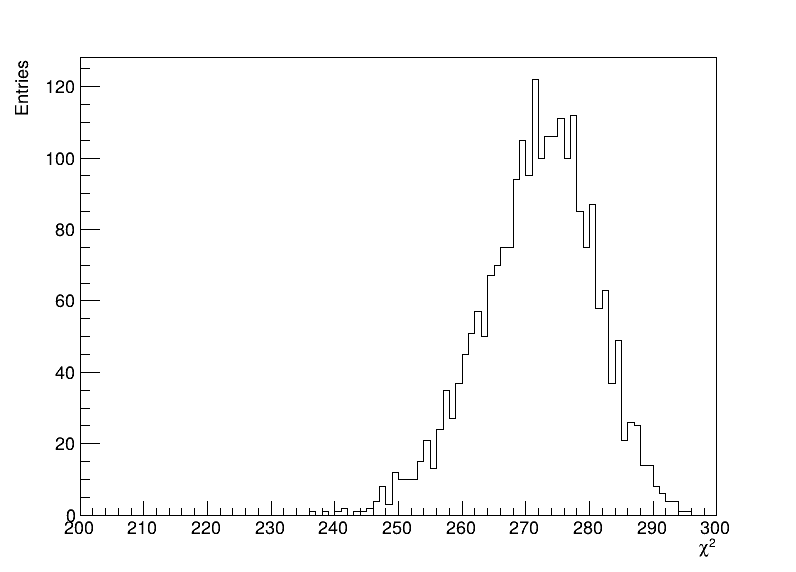

In [72]:
out_pdf_dir = "/d/home/septian/EtaPi0Plot/"
print("Chi2 values:", chi2_values)
# Create a histogram to visualize the chi2 values
ROOT.gStyle.SetOptStat(0)
chi2_hist = ROOT.TH1F("chi2_hist", ";#chi^{2};Entries", 100, 200, 300)
for file, chi2 in chi2_values:
    chi2_hist.Fill(chi2)

canvas = ROOT.TCanvas("canvas", "Chi2 Histogram", 800, 600)
chi2_hist.SetLineColor(ROOT.kBlack)
chi2_hist.Draw()
canvas.Draw()
# canvas.Print(out_pdf_dir + "Mom2Amps_chi2_10000.pdf")

In [6]:
# create df for the 5 files with lowest chi2 value
root_files = []
for file, chi2 in chi2_values[:Nfiles]:
    print(f"Processing file: {file}")
    root_file = ROOT.TFile.Open(file)
    root_files.append(root_file)

tree_result = []
for root_file in root_files:
    tree = root_file.Get("result")
    if not tree:
        print(f"Tree 'result' not found in file {root_file.GetName()}")
        continue
    tree_result.append(tree)

Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_2003.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_4133.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_4889.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_2591.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_3811.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_3640.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_2656.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_2663.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_8449.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_1538.root
Processing file: /d/home/septian/Moments2Amplitudes/brufit/MassDependentResults_765.root
Processing 

In [7]:
tree_result[0].Print()  # Print the structure of the first tree

******************************************************************************
*Tree    :result    : result                                                 *
*Entries :       20 : Total =           27769 bytes  File  Size =      10440 *
*        :          : Tree compression factor =   1.03                       *
******************************************************************************
*Br    0 :mass_bin  : mass_bin/D                                             *
*Entries :       20 : Total  Size=        742 bytes  File Size  =        206 *
*Baskets :        1 : Basket Size=      32000 bytes  Compression=   1.15     *
*............................................................................*
*Br    1 :a_0_0     : a_0_0/D                                                *
*Entries :       20 : Total  Size=        727 bytes  File Size  =        234 *
*Baskets :        1 : Basket Size=      32000 bytes  Compression=   1.00     *
*...................................................

In [8]:
def MakeAmplitudeSqrVsMass(tree, amp_name):
    gr = ROOT.TGraph()
    gr.SetName(f"{amp_name}_sqr_vs_mass")
    gr.SetTitle(f"{amp_name} squared vs Mass")
    gr.GetXaxis().SetTitle("Mass (GeV/c^{2})")
    gr.GetYaxis().SetTitle(f"{amp_name} squared (GeV/c^{2})^{2}")
    tree.SetBranchStatus("*", 0)  # Disable all branches
    tree.SetBranchStatus("mass_bin", 1)  # Enable only mass_bin branch
    tree.SetBranchStatus(amp_name, 1)  # Enable the specific amplitude branch
    for entry in tree:
        mass = tree.GetLeaf("mass_bin").GetValue()
        amp_value = tree.GetLeaf(amp_name).GetValue()
        gr.SetPoint(gr.GetN(), mass, amp_value*amp_value)
    return gr

In [9]:
df = ROOT.RDataFrame(tree_result[0])
col_names = df.GetColumnNames()

In [10]:
# print("Column names in the DataFrame:", col_names)
amp_col_names = [col for col in col_names if not col.startswith("aphi_") and not col.startswith("bphi_") and not col.startswith("mass_bin")]

print("Amplitude column names:")
for col in amp_col_names:
    print(col)

Amplitude column names:
a_0_0
a_1_-1
a_1_0
a_1_1
a_2_-1
a_2_-2
a_2_0
a_2_1
a_2_2
b_0_0
b_1_-1
b_1_0
b_1_1
b_2_-1
b_2_-2
b_2_0
b_2_1
b_2_2


In [11]:
gr_amp_vs_mass = {}
for itree in range(len(tree_result)):
    tree = tree_result[itree]
    chi2 = chi2_values[itree][1]
    for amp_name in amp_col_names:
        print(f"Processing amplitude: {amp_name} for tree {itree}")
        gr = MakeAmplitudeSqrVsMass(tree, f"{amp_name}")
        gr_amp_vs_mass[f"{amp_name}_{itree}"] = [chi2, gr]

Processing amplitude: a_0_0 for tree 0
Processing amplitude: a_1_-1 for tree 0
Processing amplitude: a_1_0 for tree 0
Processing amplitude: a_1_1 for tree 0
Processing amplitude: a_2_-1 for tree 0
Processing amplitude: a_2_-2 for tree 0
Processing amplitude: a_2_0 for tree 0
Processing amplitude: a_2_1 for tree 0
Processing amplitude: a_2_2 for tree 0
Processing amplitude: b_0_0 for tree 0
Processing amplitude: b_1_-1 for tree 0
Processing amplitude: b_1_0 for tree 0
Processing amplitude: b_1_1 for tree 0
Processing amplitude: b_2_-1 for tree 0
Processing amplitude: b_2_-2 for tree 0
Processing amplitude: b_2_0 for tree 0
Processing amplitude: b_2_1 for tree 0
Processing amplitude: b_2_2 for tree 0
Processing amplitude: a_0_0 for tree 1
Processing amplitude: a_1_-1 for tree 1
Processing amplitude: a_1_0 for tree 1
Processing amplitude: a_1_1 for tree 1
Processing amplitude: a_2_-1 for tree 1
Processing amplitude: a_2_-2 for tree 1
Processing amplitude: a_2_0 for tree 1
Processing ampli

In [12]:
import sys
sys.path.append("/d/home/septian/EtaPi0Analysis/jupyter_notebook/")
import BruFitResults as FitResults

In [13]:
fit_result_dir_Phase1_GlueX2020_nominal = "/d/home/septian/EtaPi0Analysis/run_merged/fitMoment_GlueX1_2019_11_t010100_m010200_MCMCN6000BI1000S08WCOV_R6.34/"

mass_name = "Mpi0eta"
N_mass_bin = 30
mass_bin_width = 0.04
first_mass_bin_center = 0.82

mass_bin = [first_mass_bin_center + mass_bin_width * i for i in range(N_mass_bin)]
mass_bin_dir = [f"{mass_name}{mass:.6f}_/" for mass in mass_bin]

MCMCResults_Phase1_GlueX2020_nominal = FitResults.MomentsMCMC(fit_result_dir_Phase1_GlueX2020_nominal, mass_bin_dir, mass_name)

In [14]:
gr_H000 = MCMCResults_Phase1_GlueX2020_nominal.load_saved_unnormalized_moments_vs_mass(fit_result_dir_Phase1_GlueX2020_nominal + "Moments_unnormalized_vs_mass_Phase1_GlueX2020.root", "H_0_0_0")

In [79]:
canvas_a_2 = ROOT.TCanvas("canvas_a_2", "D-waves positive refl amp. squared vs Mass", 3000, 600)
ROOT.gStyle.SetOptTitle(0)

refl_dict = {"a": "+", "b": "-"}
l_dict = {"0": "S", "1": "P", "2": "D", "3": "F", "4": "G"}

col_a_2_names = [col for col in amp_col_names if col.startswith("a_2")]
canvas_a_2.Divide(len(col_a_2_names), 1)
for j,name in enumerate(col_a_2_names):
    canvas_a_2.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(2)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    legend = ROOT.TLegend(0.75, 0.7, 1.0, 0.9)

    legend.AddEntry(gr_H000, "H_{0}(0,0)", "lpe")
    legend.SetTextSize(0.06)
    legend.SetBorderSize(0)
    legend.SetFillColorAlpha(0, 0.0)
    for i in range(len(tree_result)):
        # canvas_a_2_2.cd(i + 1)
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        # gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(12, 0.2)
        gr.SetLineWidth(2)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("C same")
        if (i==0):
            legend.AddEntry(gr, f"{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}", "l")
    legend.DrawClone()

# canvas_a_2_2.BuildLegend()
canvas_a_2.Draw()
canvas_a_2.Print(out_pdf_dir + "Mom2Amps_a_2_vs_mass.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_a_2
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Mom2Amps_a_2_vs_mass.pdf has been created


In [ ]:
canvas_b_2 = ROOT.TCanvas("canvas_b_2", "D-waves negative refl amp. squared vs Mass", 3000, 600)
canvas_b_2.Divide(len(col_a_2_names), 1)
col_b_2_names = [col for col in amp_col_names if col.startswith("b_2")]
for j,name in enumerate(col_b_2_names):
    canvas_b_2.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(2)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    
    legend = ROOT.TLegend(0.75, 0.7, 1.0, 0.9)
    legend.AddEntry(gr_H000, "H_{0}(0,0)", "lpe")
    legend.SetTextSize(0.06)
    legend.SetBorderSize(0)
    legend.SetFillColorAlpha(0, 0.0)

    for i in range(len(tree_result)):
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        # gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(12, 0.2)
        gr.SetLineWidth(2)
        gr.SetMarkerStyle(20)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("C same")
        if (i==0):
            legend.AddEntry(gr, f"{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}", "l")
    
    legend.DrawClone()
    


canvas_b_2.Draw()
canvas_b_2.Print(out_pdf_dir + "Mom2Amps_b_2_vs_mass.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_b_2
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Mom2Amps_b_2_vs_mass.pdf has been created


In [84]:
a_1_names = [col for col in amp_col_names if col.startswith("a_1")]
canvas_a_1 = ROOT.TCanvas("canvas_a_1", "P-waves positive refl amp. squared vs Mass", 1800, 600)
canvas_a_1.Divide(len(a_1_names), 1)
for j,name in enumerate(a_1_names):
    canvas_a_1.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(2)

    legend = ROOT.TLegend(0.75, 0.7, 1.0, 0.9)
    legend.AddEntry(gr_H000, "H_{0}(0,0)", "lpe")
    legend.SetTextSize(0.06)
    legend.SetBorderSize(0)
    legend.SetFillColorAlpha(0, 0.0)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    for i in range(len(tree_result)):
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        # gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(12, 0.2)
        gr.SetLineWidth(2)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("C same")
        if (i==0):
            legend.AddEntry(gr, f"{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}", "l")
    
    legend.DrawClone()
# canvas_a_1.BuildLegend()
canvas_a_1.Draw()
canvas_a_1.Print(out_pdf_dir + "Mom2Amps_a_1_vs_mass.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_a_1
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Mom2Amps_a_1_vs_mass.pdf has been created


In [85]:
b_1_names = [col for col in amp_col_names if col.startswith("b_1")]
canvas_b_1 = ROOT.TCanvas("canvas_b_1", "P-waves negative refl amp. squared vs Mass", 1800, 600)
canvas_b_1.Divide(len(b_1_names), 1)
for j,name in enumerate(b_1_names):
    canvas_b_1.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(2)

    legend = ROOT.TLegend(0.75, 0.7, 1.0, 0.9)
    legend.AddEntry(gr_H000, "H_{0}(0,0)", "lpe")
    legend.SetTextSize(0.06)
    legend.SetBorderSize(0)
    legend.SetFillColorAlpha(0, 0.0)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    for i in range(len(tree_result)):
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        # gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(12, 0.2)
        gr.SetLineWidth(2)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("C same")
        if (i==0):
            legend.AddEntry(gr, f"{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}", "l")
    
    legend.DrawClone()

# canvas_b_1.BuildLegend()
canvas_b_1.Draw()
canvas_b_1.Print(out_pdf_dir + "Mom2Amps_b_1_vs_mass.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_b_1
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Mom2Amps_b_1_vs_mass.pdf has been created


In [83]:
ab_0_names = [col for col in amp_col_names if col.startswith("a_0") or col.startswith("b_0")]

canvas_ab_0 = ROOT.TCanvas("canvas_ab_0", "S-waves positive and negative refl amp. squared vs Mass", 1200, 600)
canvas_ab_0.Divide(len(ab_0_names), 1)
for j,name in enumerate(ab_0_names):
    canvas_ab_0.cd(j+1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(2)
    legend = ROOT.TLegend(0.75, 0.7, 1.0, 0.9)
    legend.AddEntry(gr_H000, "H_{0}(0,0)", "lpe")
    legend.SetTextSize(0.06)
    legend.SetBorderSize(0)
    legend.SetFillColorAlpha(0, 0.0)

    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = name.split("_")
    for i in range(len(tree_result)):
        chi2, gr = gr_amp_vs_mass[f"{name}_{i}"]
        gr.SetMarkerColor(i + 1)
        gr.SetLineColorAlpha(12, 0.2)
        gr.SetLineWidth(2)
        # gr.SetMarkerStyle(20 + i)
        # gr.SetTitle(f"a_2_2 vs Mass (Chi2: {chi2})")
        gr.SetTitle("#chi^{2} = " + f"{chi2:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        # if i == 0:
        #     gr.Draw("APC")  # Draw the first graph with axis
        # else:
            # gr.DrawClone("PC same")
        gr.DrawClone("C same")
        if (i==0):
            legend.AddEntry(gr, f"{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}", "l")
    
    legend.DrawClone()

# canvas_ab_0.BuildLegend()
canvas_ab_0.Draw()
canvas_ab_0.Print(out_pdf_dir + "Mom2Amps_ab_0_vs_mass.pdf")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_ab_0
Info in <TCanvas::Print>: pdf file /d/home/septian/EtaPi0Plot/Mom2Amps_ab_0_vs_mass.pdf has been created


In [65]:
def MakeAmplitudeVsMass(tree, wave_sets):
    gr = ROOT.TGraph()
    gr.SetName(f"Amplitude_vs_Mass")
    gr.SetTitle("Amplitude vs Mass")
    gr.GetXaxis().SetTitle("Mass (GeV/c^{2})")
    gr.GetYaxis().SetTitle("Amplitude (GeV/c^{2})")
    tree.SetBranchStatus("*", 0)  # Disable all branches
    tree.SetBranchStatus("mass_bin", 1)  # Enable only mass_bin branch
    for wave_set in wave_sets:
        # print(f"Enabling branch: {wave_set}")
        tree.SetBranchStatus(f"{wave_set}", 1)
    for entry in tree:
        mass = tree.GetLeaf("mass_bin").GetValue()
        amp_sum = 0.0
        for wave_set in wave_sets:
            amp_value = tree.GetLeaf(f"{wave_set}").GetValue()
            amp_sum += amp_value * amp_value
        gr.SetPoint(gr.GetN(), mass, amp_sum)
    return gr

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_ampsum


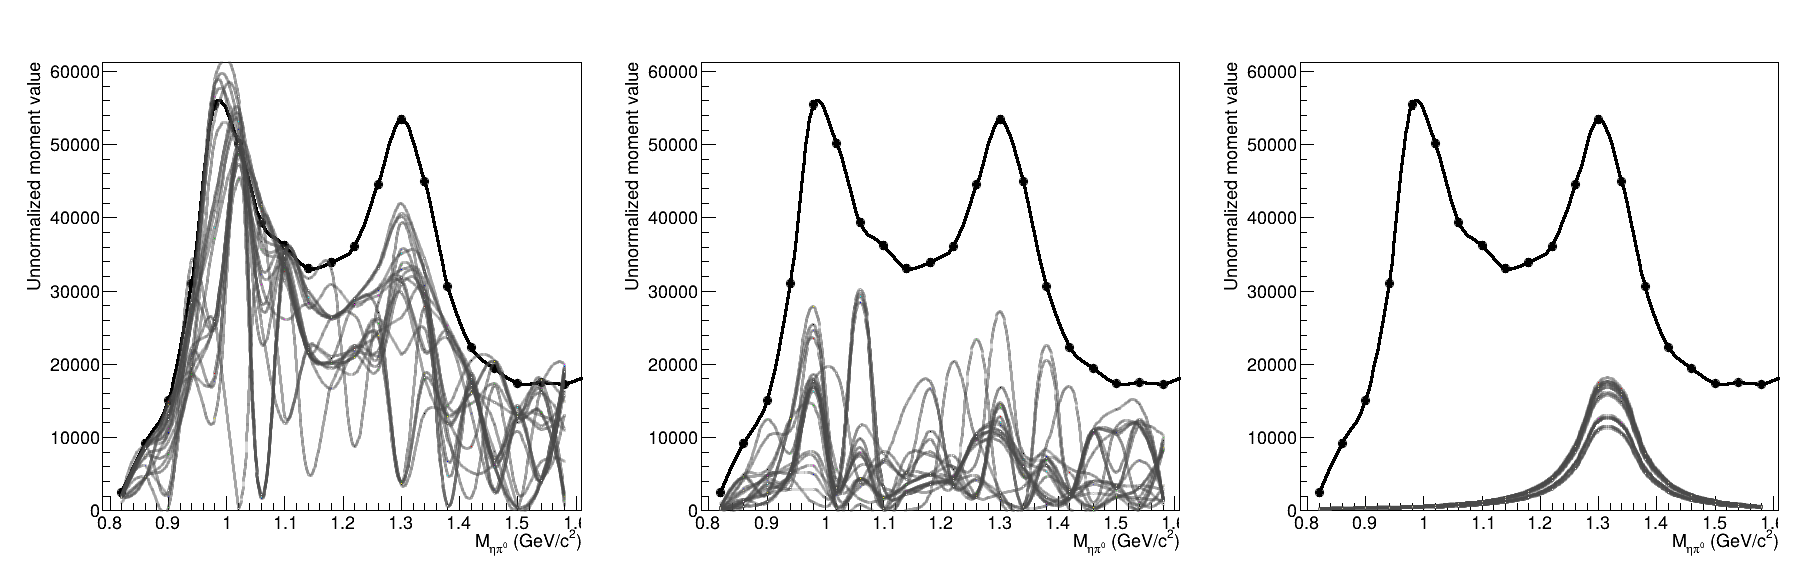

In [66]:
col_name_ab_2 = [col for col in amp_col_names if col.startswith("a_2") or col.startswith("b_2")]
col_name_ab_1 = [col for col in amp_col_names if col.startswith("a_1") or col.startswith("b_1")]
col_name_ab_0 = [col for col in amp_col_names if col.startswith("a_0") or col.startswith("b_0")]

names = [col_name_ab_0, col_name_ab_1, col_name_ab_2]

canvas_ampsum = ROOT.TCanvas("canvas_ampsum", "Amplitude Sum vs Mass", 1800, 600)
canvas_ampsum.Divide(3, 1)

for i, names in enumerate(names):
    canvas_ampsum.cd(i + 1)
    gr_H000.Draw("APC")  # Draw the H_0_0_0 graph with axis
    gr_H000.GetXaxis().SetRangeUser(0.8, 1.6)
    gr_H000.SetMinimum(0.0)
    gr_H000.SetLineWidth(3)
    ROOT.gPad.SetLeftMargin(0.15)
    ROOT.gPad.SetRightMargin(0.0)
    refl,l,m = names[0].split("_")
    for j in range(len(tree_result)):
        gr = MakeAmplitudeVsMass(tree_result[j], names)
        gr.SetMarkerColor(j + 1)
        gr.SetLineColorAlpha(12, 0.2)
        gr.SetLineWidth(3)
        gr.SetTitle("#chi^{2} = " + f"{chi2_values[j][1]:.2f}")
        gr.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
        gr.GetYaxis().SetTitle(f"|{l_dict[l]}^{{{refl_dict[refl]}}}_{{{m}}}|^{{{2}}}")
        gr.DrawClone("PC same")

canvas_ampsum.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_P_amp_sum


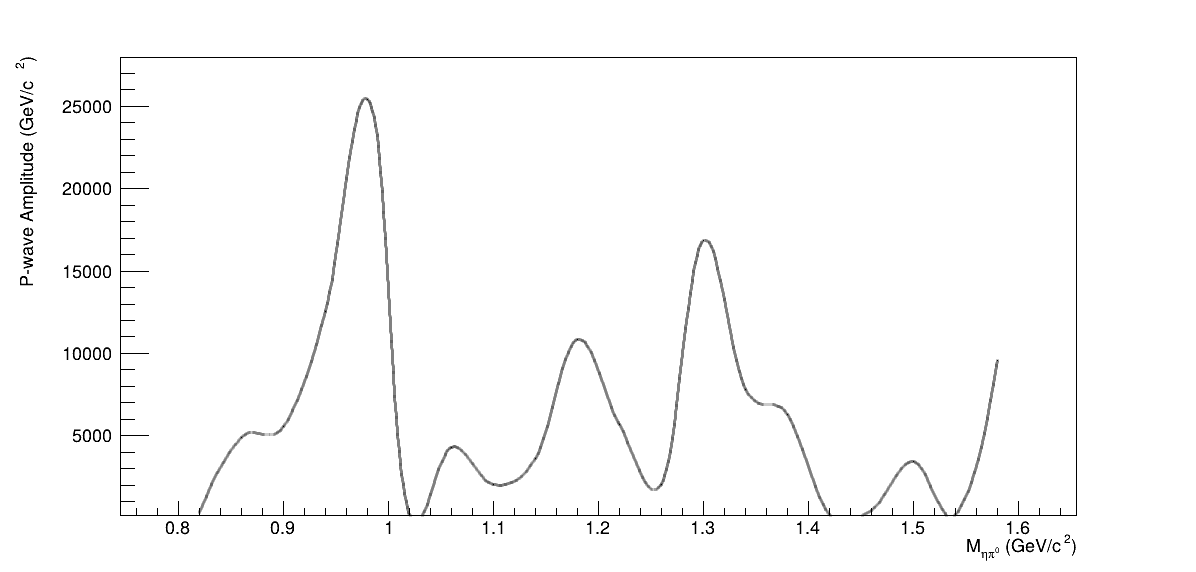

In [67]:
col_name_ab_1 = [col for col in amp_col_names if col.startswith("a_1") or col.startswith("b_1")]
gr_P_waves_sum = MakeAmplitudeVsMass(tree_result[0], col_name_ab_1)
canvas_P_amp_sum = ROOT.TCanvas("canvas_P_amp_sum", "P-wave amplitudes vs Mass", 1200, 600)
gr_P_waves_sum.SetMarkerColor(1)
gr_P_waves_sum.SetLineColorAlpha(1, 0.2)
gr_P_waves_sum.SetLineWidth(3)
gr_P_waves_sum.SetTitle("P-wave amplitudes vs Mass")
gr_P_waves_sum.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
gr_P_waves_sum.GetYaxis().SetTitle("P-wave Amplitude (GeV/c^{2})")
gr_P_waves_sum.Draw("APC")
canvas_P_amp_sum.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas_S_amp_sum


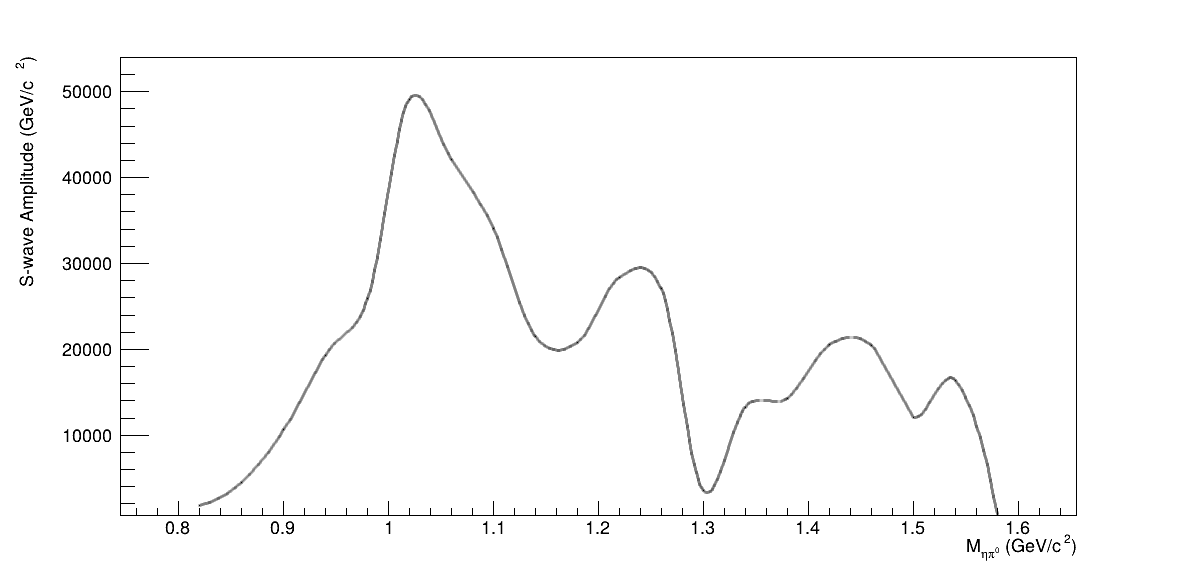

In [68]:
col_name_ab_0 = [col for col in amp_col_names if col.startswith("a_0") or col.startswith("b_0")]
gr_S_waves_sum = MakeAmplitudeVsMass(tree_result[0], col_name_ab_0)
canvas_S_amp_sum = ROOT.TCanvas("canvas_S_amp_sum", "S-wave amplitudes vs Mass", 1200, 600)
gr_S_waves_sum.SetMarkerColor(1)
gr_S_waves_sum.SetLineColorAlpha(1, 0.2)
gr_S_waves_sum.SetLineWidth(3)
gr_S_waves_sum.SetTitle("S-wave amplitudes vs Mass")
gr_S_waves_sum.GetXaxis().SetTitle("M_{#eta#pi^{0}} (GeV/c^{2})")
gr_S_waves_sum.GetYaxis().SetTitle("S-wave Amplitude (GeV/c^{2})")
gr_S_waves_sum.Draw("APC")
canvas_S_amp_sum.Draw()